In [1]:
# ─── STEP 1: Install dependencies ────────────────────────────────────────────
!pip install -q kaggle pandas numpy scikit-learn xgboost matplotlib seaborn joblib shap

In [2]:
# ─── STEP 2: Download Dataset from Kaggle ─────────────────────────────────────
# Make sure kaggle.json is at ~/.kaggle/kaggle.json
import os
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)

# Upload your kaggle.json here if on Colab:
# from google.colab import files
# files.upload()  # upload kaggle.json
# !cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d cherngs/heart-disease-cleveland-uci -p ./data --unzip
!ls ./data/

Dataset URL: https://www.kaggle.com/datasets/cherngs/heart-disease-cleveland-uci
License(s): reddit-api




  0%|          | 0.00/3.33k [00:00<?, ?B/s]
100%|██████████| 3.33k/3.33k [00:00<00:00, 7.65MB/s]
'ls' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
# ─── STEP 3: Load & Explore Data ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./data/heart_cleveland_upload.csv')
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nMissing values:\n', df.isnull().sum())
df.head()

Shape: (297, 14)

Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'condition']

Missing values:
 age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


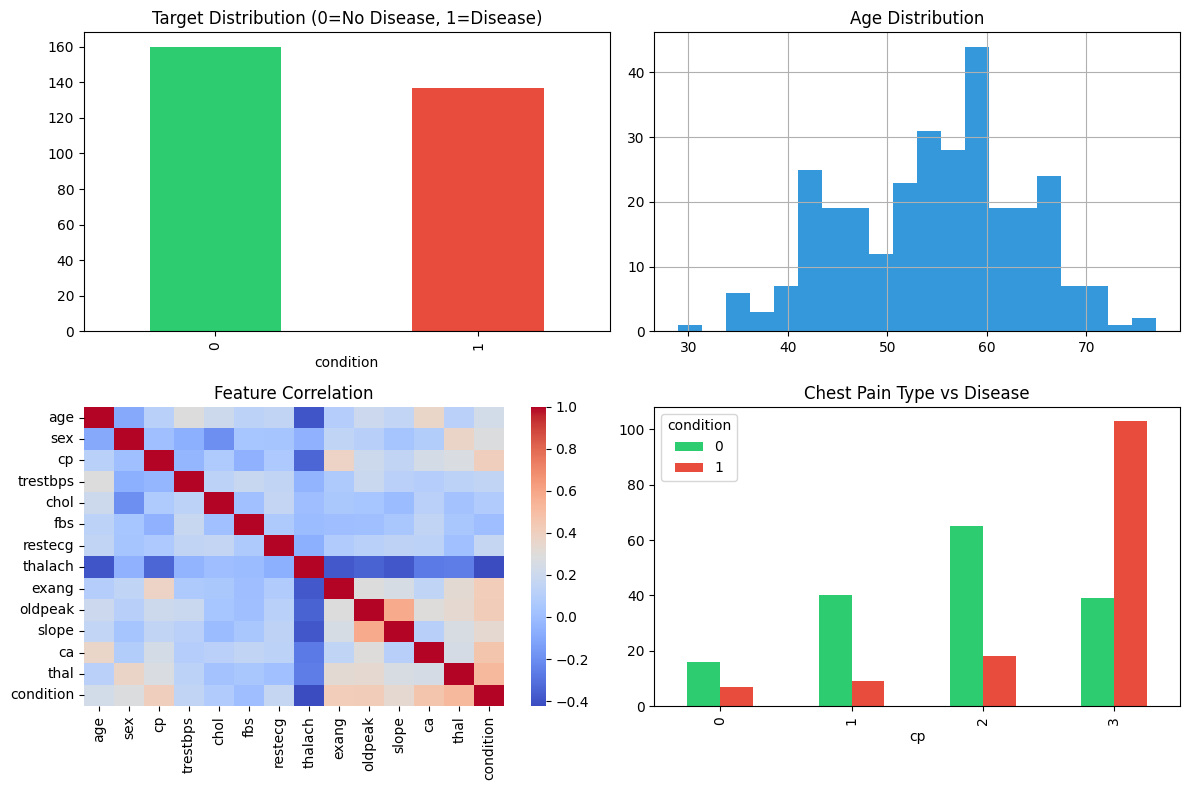

In [4]:
# ─── STEP 4: EDA ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Target distribution
df['condition'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#2ecc71','#e74c3c'])
axes[0,0].set_title('Target Distribution (0=No Disease, 1=Disease)')

# Age distribution
df['age'].hist(ax=axes[0,1], bins=20, color='#3498db')
axes[0,1].set_title('Age Distribution')

# Correlation heatmap
sns.heatmap(df.corr(), ax=axes[1,0], cmap='coolwarm', annot=False)
axes[1,0].set_title('Feature Correlation')

# Chest pain type vs condition
pd.crosstab(df['cp'], df['condition']).plot(kind='bar', ax=axes[1,1], color=['#2ecc71','#e74c3c'])
axes[1,1].set_title('Chest Pain Type vs Disease')

plt.tight_layout()
plt.savefig('./data/heart_eda.png', dpi=100)
plt.show()

In [5]:
# ─── STEP 5: Preprocessing ────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X = df.drop('condition', axis=1)
y = df['condition']

# Save feature names for API use
FEATURE_NAMES = X.columns.tolist()
print('Features:', FEATURE_NAMES)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Train: (237, 13), Test: (60, 13)


In [6]:
# ─── STEP 6: Train Multiple Models ────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

models = {
    'RandomForest': RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, 
                              use_label_encoder=False, eval_metric='logloss', random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42)
}

results = {}
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    preds = model.predict(X_test_sc)
    proba = model.predict_proba(X_test_sc)[:, 1]
    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, proba)
    results[name] = {'accuracy': acc, 'auc': auc}
    print(f'{name}: Accuracy={acc:.4f}, AUC={auc:.4f}')

best_model_name = max(results, key=lambda k: results[k]['auc'])
print(f'\n✅ Best Model: {best_model_name}')

RandomForest: Accuracy=0.8667, AUC=0.9353


d:\HEALTH AI\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [03:54:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost: Accuracy=0.8500, AUC=0.9342
GradientBoosting: Accuracy=0.8333, AUC=0.9241
LogisticRegression: Accuracy=0.9167, AUC=0.9531

✅ Best Model: LogisticRegression


In [7]:
# ─── STEP 7: Build Final Ensemble (Voting) ────────────────────────────────────
final_model = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)),
        ('xgb', XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                               use_label_encoder=False, eval_metric='logloss', random_state=42)),
        ('gb', GradientBoostingClassifier(n_estimators=200, random_state=42))
    ],
    voting='soft'
)

final_model.fit(X_train_sc, y_train)
final_preds = final_model.predict(X_test_sc)
final_proba = final_model.predict_proba(X_test_sc)[:, 1]

print('=== FINAL ENSEMBLE RESULTS ===')
print(f'Accuracy: {accuracy_score(y_test, final_preds):.4f}')
print(f'AUC-ROC: {roc_auc_score(y_test, final_proba):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, final_preds, target_names=['No Disease', 'Disease']))

d:\HEALTH AI\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [03:55:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== FINAL ENSEMBLE RESULTS ===
Accuracy: 0.8167
AUC-ROC: 0.9531

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.77      0.94      0.85        32
     Disease       0.90      0.68      0.78        28

    accuracy                           0.82        60
   macro avg       0.84      0.81      0.81        60
weighted avg       0.83      0.82      0.81        60



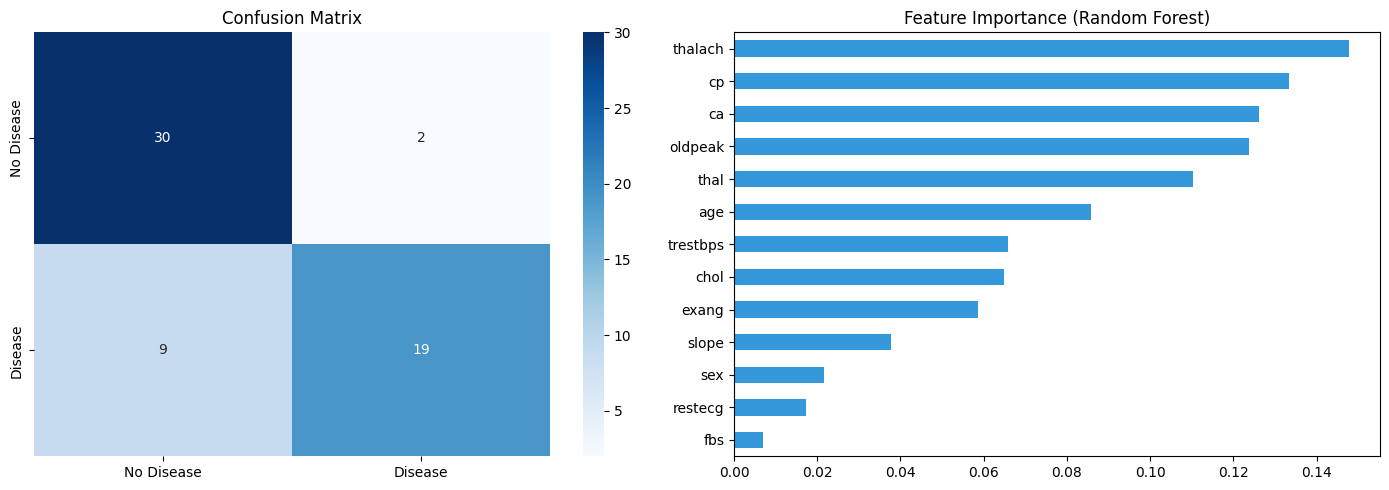

In [8]:
# ─── STEP 8: Confusion Matrix & Feature Importance ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, final_preds)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0], 
            xticklabels=['No Disease','Disease'], yticklabels=['No Disease','Disease'],
            cmap='Blues')
axes[0].set_title('Confusion Matrix')

# Feature Importance from RF sub-model
rf_sub = final_model.estimators_[0]
feat_imp = pd.Series(rf_sub.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=True)
feat_imp.plot(kind='barh', ax=axes[1], color='#3498db')
axes[1].set_title('Feature Importance (Random Forest)')

plt.tight_layout()
plt.savefig('./data/heart_results.png', dpi=100)
plt.show()

In [9]:
# ─── STEP 9: Save Model ───────────────────────────────────────────────────────
import joblib
import json
import os

os.makedirs('./output', exist_ok=True)

# Save model + scaler together as a bundle
bundle = {
    'model': final_model,
    'scaler': scaler,
    'feature_names': FEATURE_NAMES,
    'classes': ['No Disease', 'Disease'],
    'threshold': 0.5
}

joblib.dump(bundle, './output/heart_model.pkl')
print('✅ Saved: ./output/heart_model.pkl')
print('\n📁 COPY THIS FILE TO: healthvision-ai/ai-server/models/heart_model.pkl')

✅ Saved: ./output/heart_model.pkl

📁 COPY THIS FILE TO: healthvision-ai/ai-server/models/heart_model.pkl


In [10]:
# ─── STEP 10: Test Prediction (matches ai-server/services/heart_service.py) ──
sample_input = {
    'age': 63, 'sex': 1, 'cp': 3, 'trestbps': 145,
    'chol': 233, 'fbs': 1, 'restecg': 0, 'thalach': 150,
    'exang': 0, 'oldpeak': 2.3, 'slope': 0, 'ca': 0, 'thal': 1
}

loaded = joblib.load('./output/heart_model.pkl')
input_df = pd.DataFrame([sample_input])[loaded['feature_names']]
input_sc = loaded['scaler'].transform(input_df)
prob = loaded['model'].predict_proba(input_sc)[0][1]

print(f'Risk Probability: {prob:.4f} ({prob*100:.1f}%)')
print(f'Prediction: {"❗ Heart Disease Detected" if prob > 0.5 else "✅ No Heart Disease"}')

Risk Probability: 0.3861 (38.6%)
Prediction: ✅ No Heart Disease
